In [1]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')


import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import librosa
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np
from utils import apply_bandpass_filter, get_optimizer, get_class_weights, get_monitor, plot_confusion_matrix, plot_training_history, encode_labels, perform_patient_split
import librosa

LOWCUT, HIGHCUT = 20, 500   
SEGMENT_EXTENSION_MS = 3

data = "../features-extraction/features-relative.csv"

df = pd.read_csv(data)

filtered_signals = {} 

df["file"] = df["file"].apply(lambda p: p.replace("\\", "/"))

for file_path in df["file"].unique():
    signal, fs = librosa.load(file_path)
    
    signal_filtered = apply_bandpass_filter(signal, fs)
    filtered_signals[file_path] = (signal_filtered, fs)

2025-12-18 07:43:30.607328: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 07:43:30.690542: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    file_path = file_path.replace('\\', '/')
    signal_filtered, fs = filtered_signals[file_path]
    
    start_sample = row["Start"]
    end_sample = row["End"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment


max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

X = np.stack(features, axis=-1)
print("X shape:", X.shape)  
print("Feature channels:", len(features))

def remap_label(label):
    label_lower = str(label).strip().lower()
    if label_lower in ['psw', 'fibrillation']:
        return 'positive'
    elif label_lower == "nan":
        return 'none'
    else:
        return str(label)  
    
def labels_to_string(label):
    label_lower = str(label).strip().lower()
    if label_lower == "nan":
        return 'none'
    else:
        return str(label)

df['Label_Remapped'] = df['Label'].apply(labels_to_string)

train_mask, test_mask, y_train, y_test = perform_patient_split(
    df,
    label_col="Label_Remapped"
)

X_train = X[train_mask]
X_test  = X[test_mask]

y_train, y_test, labels = encode_labels(y_train, y_test)



X shape: (4313, 979, 1)
Feature channels: 1


In [3]:


n_channels = X.shape[-1]

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  
    MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
from tensorflow import keras
from sklearn.utils import shuffle

model.compile(
    optimizer=get_optimizer(),  
    loss='sparse_categorical_crossentropy',  
    metrics=["accuracy"]
)
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[get_monitor()],
                    class_weight=get_class_weights(y_train))

Epoch 1/100


2025-12-18 07:43:37.000737: I external/local_xla/xla/service/service.cc:163] XLA service 0x774a8800e600 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-18 07:43:37.000764: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-18 07:43:37.041624: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 1/99 ━━━━━━━━━━━━━━━━━━━━ 3:54 2s/step - accuracy: 0.5000 - loss: 1.1354

I0000 00:00:1766043817.720600  243113 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.4852 - loss: 1.0562 - val_accuracy: 0.8195 - val_loss: 0.9467
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6471 - loss: 0.8982 - val_accuracy: 0.6533 - val_loss: 1.0768
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.6819 - loss: 0.8398 - val_accuracy: 0.8739 - val_loss: 0.6551
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.6898 - loss: 0.8127 - val_accuracy: 0.8968 - val_loss: 0.5874
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.7032 - loss: 0.7918 - val_accuracy: 0.8997 - val_loss: 0.5484
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.7023 - loss: 0.7800 - val_accuracy: 0.7163 - val_loss: 0.9264
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.7329 - loss: 0.7468 - val_accuracy: 0.9083 - val_loss: 0.5200
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7415 - loss: 0.7078 - val_accuracy: 0.6991 - val_

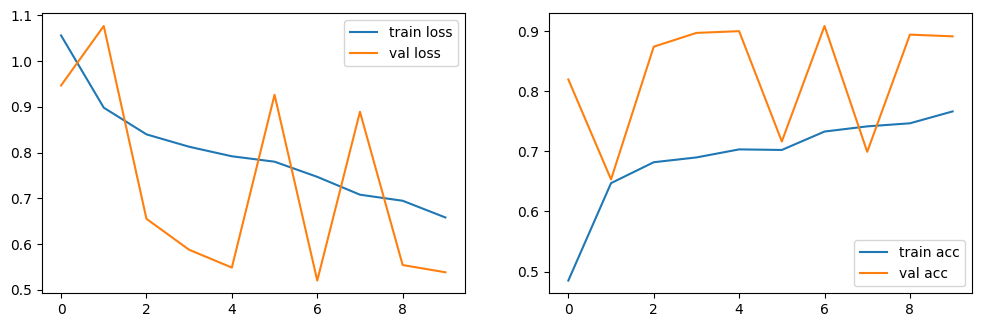

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


<Figure size 600x500 with 0 Axes>

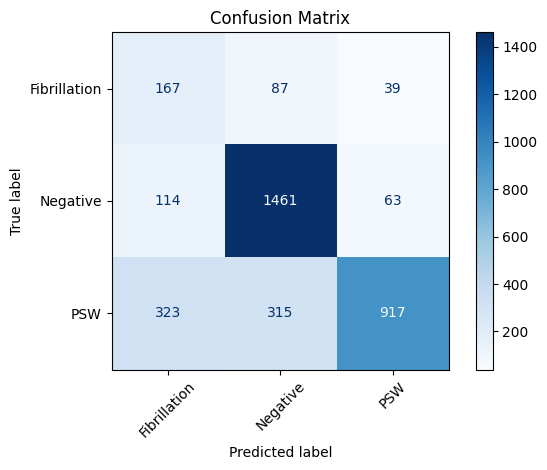


Classification Report:
              precision    recall  f1-score   support

Fibrillation       0.28      0.57      0.37       293
    Negative       0.78      0.89      0.83      1638
         PSW       0.90      0.59      0.71      1555

    accuracy                           0.73      3486
   macro avg       0.65      0.68      0.64      3486
weighted avg       0.79      0.73      0.74      3486



In [5]:
plot_training_history(history)

y_pred = model.predict(X_train)
y_pred_classes = np.argmax(y_pred, axis=1)

plot_confusion_matrix(y_train, y_pred_classes, labels)